<h1 align="center">3. Análise de Vulnerabilidade</h1>

<h3>Métricas de Centralidade</h3>

In [ ]:


# 1. DEGREE CENTRALITY
print("1/3 Degree centrality...")
degree_cent = nx.degree_centrality(G_principal)

# 2. BETWEENNESS CENTRALITY
print("2/3 Betweenness centrality (k=500)...")
betweenness_cent = nx.betweenness_centrality(G_principal, k=500, seed=42)

# 3. CLOSENESS CENTRALITY
print("3/3 Closeness centrality...")
closeness_cent = nx.closeness_centrality(G_principal)


# Montar DataFrame de métricas
metricas = pd.DataFrame({
    'stop_id': list(G_principal.nodes()),
    'degree': [G_principal.degree(n) for n in G_principal.nodes()],
    'degree_centrality': [degree_cent[n] for n in G_principal.nodes()],
    'betweenness_centrality': [betweenness_cent[n] for n in G_principal.nodes()],
    'closeness_centrality': [closeness_cent[n] for n in G_principal.nodes()],
})

# Enriquecer com atributos dos nós
metricas['stop_name'] = metricas['stop_id'].map(lambda n: G_principal.nodes[n].get('name', ''))
metricas['lat'] = metricas['stop_id'].map(lambda n: G_principal.nodes[n].get('lat', np.nan))
metricas['lon'] = metricas['stop_id'].map(lambda n: G_principal.nodes[n].get('lon', np.nan))
metricas['modal'] = metricas['stop_id'].map(lambda n: G_principal.nodes[n].get('modal', 'desconhecido'))

print(f"\nEstatísticas das métricas:")
print(metricas[['degree', 'degree_centrality', 'betweenness_centrality', 'closeness_centrality']].describe())

1/3 Degree centrality...
2/3 Betweenness centrality (k=500)...
3/3 Closeness centrality...

Concluído!

Estatísticas das métricas:
             degree  degree_centrality  betweenness_centrality  \
count  22099.000000       22099.000000            22099.000000   
mean       2.910810           0.000132                0.001437   
std        2.328362           0.000105                0.009120   
min        1.000000           0.000045                0.000000   
25%        2.000000           0.000091                0.000040   
50%        2.000000           0.000091                0.000140   
75%        3.000000           0.000136                0.000542   
max       63.000000           0.002851                0.380227   

       closeness_centrality  
count          22099.000000  
mean               0.032519  
std                0.007057  
min                0.011994  
25%                0.027528  
50%                0.032014  
75%                0.037458  
max                0.052827  


In [ ]:
# Ranking 15 por métrica

for metrica in ['degree', 'betweenness_centrality', 'closeness_centrality']:
    print(f"\n{'='*70}")
    print(f"  TOP 15 — {metrica.upper()}")
    print(f"{'='*70}")
    top = metricas.nlargest(15, metrica)[
        ['stop_name', 'modal', 'degree', 'betweenness_centrality', 'closeness_centrality']
    ]
    top_display = top.copy()
    top_display['betweenness_centrality'] = top_display['betweenness_centrality'].map('{:.6f}'.format)
    top_display['closeness_centrality'] = top_display['closeness_centrality'].map('{:.6f}'.format)
    top_display.index = range(1, 16)
    print(top_display.to_string())

# Sobreposição entre rankings
top_deg = set(metricas.nlargest(15, 'degree')['stop_id'])
top_bet = set(metricas.nlargest(15, 'betweenness_centrality')['stop_id'])
top_clo = set(metricas.nlargest(15, 'closeness_centrality')['stop_id'])

print(f"\n{'='*70}")
print(f"  SOBREPOSIÇÃO ENTRE RANKINGS")
print(f"{'='*70}")
print(f"  Degree ∩ Betweenness:   {len(top_deg & top_bet)} de 15")
print(f"  Degree ∩ Closeness:     {len(top_deg & top_clo)} de 15")
print(f"  Betweenness ∩ Closeness: {len(top_bet & top_clo)} de 15")
print(f"  Nos 3 rankings simultaneamente: {len(top_deg & top_bet & top_clo)} de 15")


  TOP 15 — DEGREE
                  stop_name   modal  degree betweenness_centrality closeness_centrality
1                   Santana   metro      63               0.114060             0.043573
2      Corinthians-itaquera    cptm      61               0.203033             0.049659
3               Largo Treze   metro      61               0.035304             0.037776
4      Corinthians-itaquera   metro      60               0.021092             0.045741
5            Lapa (linha 8)    cptm      59               0.142682             0.047906
6                    Grajaú    cptm      46               0.104129             0.033101
7                  Pirituba    cptm      46               0.106190             0.043557
8                Anhangabaú   metro      46               0.006701             0.049840
9                São Mateus   metro      45               0.044280             0.034083
10       Av. Pe. José Maria  onibus      43               0.001014             0.037112
11           

In [ ]:
print("Distribuição por modal nos top 15 de cada métrica:\n")

for metrica in ['degree', 'betweenness_centrality', 'closeness_centrality']:
    top15 = metricas.nlargest(15, metrica)
    dist = top15['modal'].value_counts().to_dict()
    print(f"  {metrica}:")
    for modal, cont in dist.items():
        print(f"    {modal}: {cont}")
    print()

Distribuição por modal nos top 15 de cada métrica:

  degree:
    metro: 7
    cptm: 7
    onibus: 1

  betweenness_centrality:
    cptm: 11
    metro: 4

  closeness_centrality:
    onibus: 11
    cptm: 3
    metro: 1



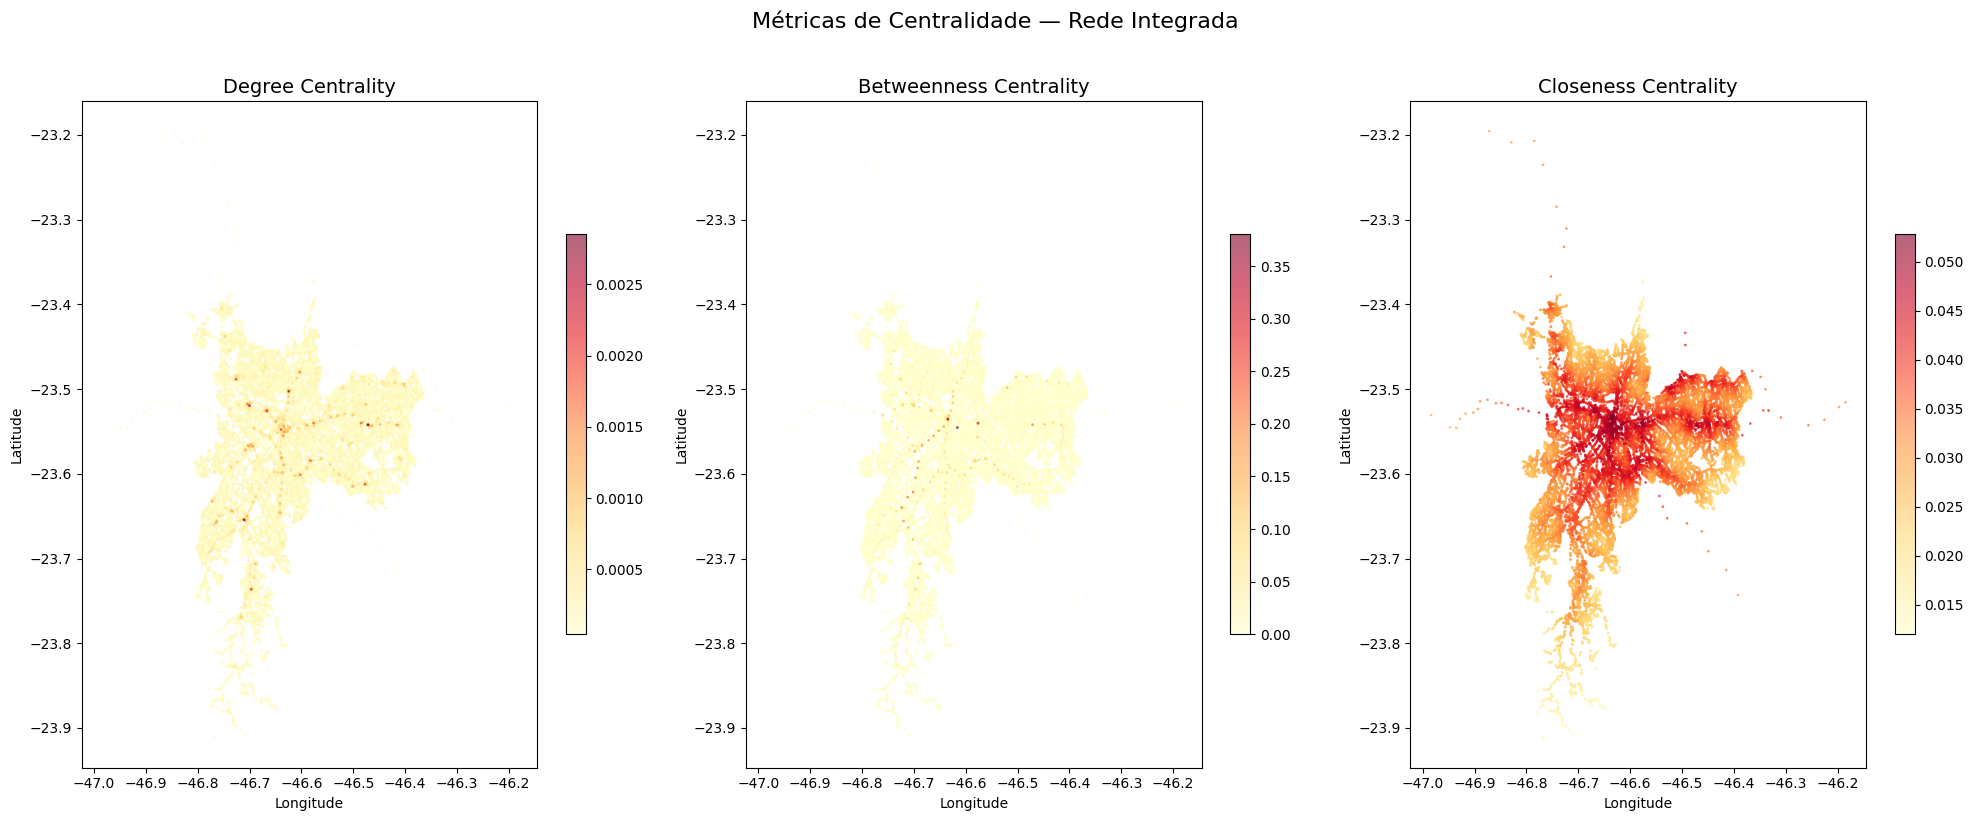

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
metricas_plot = ['degree_centrality', 'betweenness_centrality', 'closeness_centrality']
titulos = ['Degree Centrality', 'Betweenness Centrality', 'Closeness Centrality']

for ax, metrica, titulo in zip(axes, metricas_plot, titulos):
    valores = metricas[metrica].values
    ordem = np.argsort(valores)  # maiores por cima

    scatter = ax.scatter(
        metricas['lon'].values[ordem],
        metricas['lat'].values[ordem],
        c=valores[ordem],
        s=1,
        cmap='YlOrRd',
        alpha=0.6
    )
    ax.set_title(titulo, fontsize=14)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.colorbar(scatter, ax=ax, shrink=0.6)

plt.suptitle('Métricas de Centralidade — Rede Integrada', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(REPO_ROOT / 'outputs' / 'mapa_centralidades_integrado.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Ranquear em cada métrica (1 = mais importante)
metricas['rank_degree'] = metricas['degree'].rank(ascending=False)
metricas['rank_betweenness'] = metricas['betweenness_centrality'].rank(ascending=False)
metricas['rank_closeness'] = metricas['closeness_centrality'].rank(ascending=False)

# Ranking combinado = média dos 3
metricas['rank_combinado'] = (
    metricas['rank_degree'] + metricas['rank_betweenness'] + metricas['rank_closeness']
) / 3

# Top 20 mais críticos
print("TOP 20 — NÓS MAIS CRÍTICOS (ranking combinado)")
print("=" * 80)
top_criticos = metricas.nsmallest(20, 'rank_combinado')[
    ['stop_name', 'modal', 'degree', 'betweenness_centrality',
     'closeness_centrality', 'rank_combinado']
]
top_criticos.index = range(1, 21)
print(top_criticos.to_string())

print(f"\nDistribuição por modal nos top 20 mais críticos:")
print(top_criticos['modal'].value_counts())

In [ ]:
from networkx.algorithms.community import louvain_communities, modularity

print("Detectando comunidades com Louvain...")
comunidades = louvain_communities(G_principal, seed=42)

Q = modularity(G_principal, comunidades)
print(f"\nComunidades encontradas: {len(comunidades)}")
print(f"Modularidade (Q):       {Q:.4f}")
print(f"  (Q próximo de 1 = comunidades bem definidas)")

# Atribuir comunidade a cada nó
comunidades_ord = sorted(comunidades, key=len, reverse=True)
node_to_community = {}
for i, com in enumerate(comunidades_ord):
    for node in com:
        node_to_community[node] = i

metricas['comunidade'] = metricas['stop_id'].map(node_to_community)

print(f"\nTamanho das top 15 comunidades:")
for i, com in enumerate(comunidades_ord[:15]):
    pct = len(com) / G_principal.number_of_nodes() * 100
    print(f"  Comunidade {i+1}: {len(com):>5,} nós ({pct:>5.1f}%)")

if len(comunidades_ord) > 15:
    resto = sum(len(c) for c in comunidades_ord[15:])
    print(f"  + {len(comunidades_ord) - 15} comunidades menores: {resto:,} nós")

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))

n_top = min(20, len(comunidades_ord))
cmap = plt.cm.get_cmap('tab20', n_top)

for i, com in enumerate(comunidades_ord[:n_top]):
    lats = [G_principal.nodes[n].get('lat', np.nan) for n in com]
    lons = [G_principal.nodes[n].get('lon', np.nan) for n in com]
    ax.scatter(lons, lats, s=1, c=[cmap(i)], alpha=0.6,
               label=f'Com. {i+1} ({len(com):,})')

ax.set_title(f'Comunidades Louvain — {len(comunidades)} comunidades (Q={Q:.3f})', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='upper left', fontsize=7, ncol=2, markerscale=5)

plt.tight_layout()
plt.savefig(REPO_ROOT / 'outputs' / 'mapa_comunidades.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
fronteira = []

for node in G_principal.nodes():
    com_node = node_to_community.get(node)
    comunidades_vizinhas = set()

    for viz in G_principal.neighbors(node):
        com_viz = node_to_community.get(viz)
        if com_viz != com_node:
            comunidades_vizinhas.add(com_viz)

    if comunidades_vizinhas:
        fronteira.append({
            'stop_id': node,
            'stop_name': G_principal.nodes[node].get('name', ''),
            'modal': G_principal.nodes[node].get('modal', ''),
            'comunidade': com_node,
            'n_comunidades_vizinhas': len(comunidades_vizinhas),
            'betweenness': betweenness_cent.get(node, 0)
        })

df_fronteira = pd.DataFrame(fronteira)
print(f"Total de nós de fronteira: {len(df_fronteira):,}")
print(f"({len(df_fronteira)/G_principal.number_of_nodes()*100:.1f}% do total)")

print(f"\nTOP 20 NÓS DE FRONTEIRA (por betweenness):")
print("="*70)
top_front = df_fronteira.nlargest(20, 'betweenness')[
    ['stop_name', 'modal', 'comunidade', 'n_comunidades_vizinhas', 'betweenness']
]
top_front.index = range(1, 21)
print(top_front.to_string())

In [ ]:
# Salvar grafo em GraphML (pro notebook 03 de resiliência)
nx.write_graphml(G_principal, str(OUTPUT_PATH / 'grafo_sp_integrado.graphml'))
print(f"Grafo salvo: {OUTPUT_PATH / 'grafo_sp_integrado.graphml'}")

# Salvar métricas
metricas.to_csv(OUTPUT_PATH / 'metricas_centralidade_v2.csv', index=False)
print(f"Métricas salvas: {OUTPUT_PATH / 'metricas_centralidade_v2.csv'}")

# Salvar análise de estações
df_estacoes.to_csv(OUTPUT_PATH / 'analise_estacoes_transferencia.csv', index=False)
print(f"Análise de estações salva: {OUTPUT_PATH / 'analise_estacoes_transferencia.csv'}")